In [1]:
import control as ct
from math import pi

In [2]:
C=2.2E-6
L=1.65E-3

In [3]:
num = [0,C]
den = [1, L*C]
Gp=ct.tf(num,den)
print(Gp)

<TransferFunction>: sys[0]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

    2.2e-06
  ------------
  s + 3.63e-09


In [6]:
def pidtune(GH, BW, PM):
    '''Evaluate a PID control used on power eletronics.

    Parameters:
        Open loop plant*sensor transfer function.
        Bandwidth in rad/s.
        Phase margin in degrees.
    '''
    from math import sqrt, tan, radians
    from numpy import angle
    # Evaluate the plant transfer function on the intended bandwidth frequency.
    evaluated_BW = GH(1j * BW)
    evaluation_gain = abs(evaluated_BW)
    evaluation_angle = angle(evaluated_BW)
    # Evaluate the gain and margin phase that the control must apply.
    pi_gain = 1 / evaluation_gain
    pi_phase = radians(PM) - (pi - evaluation_angle)
    # Convert the gain and margin to control gain parameters.
    Kp_Ki = 1 / BW * tan( pi_phase + pi / 2 )
    Ki = pi_gain / sqrt(1 / BW ** 2 + Kp_Ki ** 2)
    Kp = Ki * Kp_Ki
    Kd = 0
    s =ct.tf('s')
    return Kp + Ki / s + Kd * s

In [19]:
aa = pidtune(Gp, 2*pi*500, 60.0)

In [20]:
print(aa)

<TransferFunction>: sys[49]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

  1.237e+09 s + 2.243e+12
  -----------------------
             s


In [21]:
sys = aa * Gp /(1+aa*Gp)
print(sys)

<TransferFunction>: sys[54]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

     2721 s^3 + 4.935e+06 s^2 + 0.01791 s
  ------------------------------------------
  s^4 + 2721 s^3 + 4.935e+06 s^2 + 0.01791 s


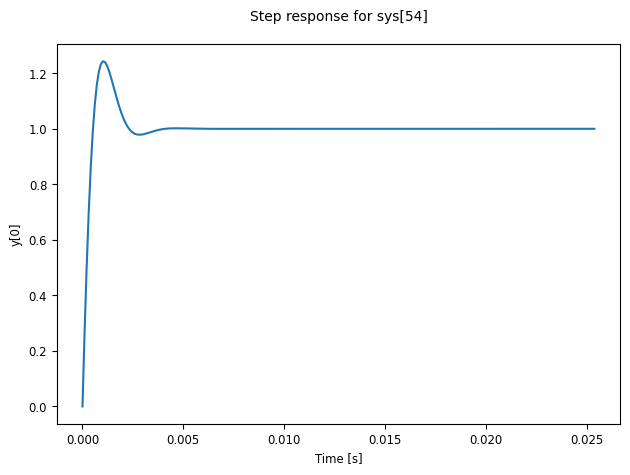

In [22]:
response = ct.step_response(sys)
cplt = response.plot()